In [317]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [318]:
df = pd.read_csv("../data/austinHousingData.csv")

In [319]:
df.head()

,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [320]:
df.shape

(15171, 47)

In [321]:
df.columns

Index(['zpid', 'city', 'streetAddress', 'zipcode', 'description', 'latitude',
       'longitude', 'propertyTaxRate', 'garageSpaces', 'hasAssociation',
       'hasCooling', 'hasGarage', 'hasHeating', 'hasSpa', 'hasView',
       'homeType', 'parkingSpaces', 'yearBuilt', 'latestPrice',
       'numPriceChanges', 'latest_saledate', 'latest_salemonth',
       'latest_saleyear', 'latestPriceSource', 'numOfPhotos',
       'numOfAccessibilityFeatures', 'numOfAppliances', 'numOfParkingFeatures',
       'numOfPatioAndPorchFeatures', 'numOfSecurityFeatures',
       'numOfWaterfrontFeatures', 'numOfWindowFeatures',
       'numOfCommunityFeatures', 'lotSizeSqFt', 'livingAreaSqFt',
       'numOfPrimarySchools', 'numOfElementarySchools', 'numOfMiddleSchools',
       'numOfHighSchools', 'avgSchoolDistance', 'avgSchoolRating',
       'avgSchoolSize', 'MedianStudentsPerTeacher', 'numOfBathrooms',
       'numOfBedrooms', 'numOfStories', 'homeImage'],
      dtype='object')

In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zpid                        15171 non-null  int64  
 1   city                        15171 non-null  object 
 2   streetAddress               15171 non-null  object 
 3   zipcode                     15171 non-null  int64  
 4   description                 15169 non-null  object 
 5   latitude                    15171 non-null  float64
 6   longitude                   15171 non-null  float64
 7   propertyTaxRate             15171 non-null  float64
 8   garageSpaces                15171 non-null  int64  
 9   hasAssociation              15171 non-null  bool   
 10  hasCooling                  15171 non-null  bool   
 11  hasGarage                   15171 non-null  bool   
 12  hasHeating                  15171 non-null  bool   
 13  hasSpa                      151

In [323]:
df.describe()

,zpid,zipcode,latitude,longitude,propertyTaxRate,garageSpaces,parkingSpaces,yearBuilt,latestPrice,numPriceChanges,...,numOfElementarySchools,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories
count,1.517100e+04,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,1.517100e+04,15171.000000,...,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000
mean,1.044193e+08,78735.932964,30.291596,-97.778532,1.994085,1.229187,1.224507,1988.554743,5.127677e+05,3.032892,...,0.049173,1.035990,0.976798,1.838495,5.779912,1237.304660,14.857228,2.683010,3.440380,1.467273
std,3.179426e+08,18.893475,0.096973,0.084715,0.053102,1.352117,1.352732,21.579458,4.531853e+05,2.487392,...,0.234937,0.263633,0.292043,1.068376,1.860276,326.513311,1.741857,1.054445,0.849942,0.523697
min,2.858495e+07,78617.000000,30.085030,-98.022057,1.980000,0.000000,0.000000,1905.000000,5.500000e+03,1.000000,...,0.000000,0.000000,0.000000,0.200000,2.333333,396.000000,10.000000,0.000000,0.000000,1.000000
25%,2.941115e+07,78727.000000,30.203313,-97.838009,1.980000,0.000000,0.000000,1974.000000,3.090000e+05,1.000000,...,0.000000,1.000000,1.000000,1.100000,4.000000,966.000000,14.000000,2.000000,3.000000,1.000000
50%,2.949441e+07,78739.000000,30.284416,-97.769539,1.980000,1.000000,1.000000,1993.000000,4.050000e+05,2.000000,...,0.000000,1.000000,1.000000,1.566667,5.778694,1287.000000,15.000000,3.000000,3.000000,1.000000
75%,7.033762e+07,78749.000000,30.366585,-97.717903,1.980000,2.000000,2.000000,2006.000000,5.750000e+05,4.000000,...,0.000000,1.000000,1.000000,2.266667,7.000000,1496.000000,16.000000,3.000000,4.000000,2.000000
max,2.146313e+09,78759.000000,30.517323,-97.569504,2.210000,22.000000,22.000000,2020.000000,1.350000e+07,23.000000,...,2.000000,3.000000,2.000000,9.000000,9.500000,1913.000000,19.000000,27.000000,20.000000,4.000000


In [324]:
df.isnull().sum()

zpid                          0
city                          0
streetAddress                 0
zipcode                       0
description                   2
latitude                      0
longitude                     0
propertyTaxRate               0
garageSpaces                  0
hasAssociation                0
hasCooling                    0
hasGarage                     0
hasHeating                    0
hasSpa                        0
hasView                       0
homeType                      0
parkingSpaces                 0
yearBuilt                     0
latestPrice                   0
numPriceChanges               0
latest_saledate               0
latest_salemonth              0
latest_saleyear               0
latestPriceSource             0
numOfPhotos                   0
numOfAccessibilityFeatures    0
numOfAppliances               0
numOfParkingFeatures          0
numOfPatioAndPorchFeatures    0
numOfSecurityFeatures         0
numOfWaterfrontFeatures       0
numOfWin

In [325]:
df["latestPrice"].describe()

count    1.517100e+04
mean     5.127677e+05
std      4.531853e+05
min      5.500000e+03
25%      3.090000e+05
50%      4.050000e+05
75%      5.750000e+05
max      1.350000e+07
Name: latestPrice, dtype: float64

In [326]:
df["city"].value_counts().head(10)

city
austin              15020
del valle              86
pflugerville           36
driftwood              12
manor                   6
dripping springs        5
manchaca                3
west lake hills         2
road                    1
Name: count, dtype: int64

In [327]:
df["latestPrice"].sort_values(ascending=False).head(10)

2316     13500000.0
14275    13000000.0
1399     12720000.0
290       8999000.0
14639     8799000.0
1298      8750000.0
14376     8750000.0
14395     6499000.0
14627     6250000.0
1360      6200000.0
Name: latestPrice, dtype: float64

In [328]:
df["latestPrice"].quantile([0.90, 0.95, 0.99, 0.995])

0.900     825000.0
0.950    1150000.0
0.990    2312800.0
0.995    2950000.0
Name: latestPrice, dtype: float64

In [329]:
df[[
    "latestPrice",
    "numOfBedrooms",
    "numOfBathrooms",
    "livingAreaSqFt",
    "yearBuilt",
    "garageSpaces",
    "parkingSpaces"
]].describe()

,latestPrice,numOfBedrooms,numOfBathrooms,livingAreaSqFt,yearBuilt,garageSpaces,parkingSpaces
count,1.517100e+04,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000,15171.000000
mean,5.127677e+05,3.440380,2.683010,2208.323314,1988.554743,1.229187,1.224507
std,4.531853e+05,0.849942,1.054445,1378.576119,21.579458,1.352117,1.352732
min,5.500000e+03,0.000000,0.000000,300.000000,1905.000000,0.000000,0.000000
25%,3.090000e+05,3.000000,2.000000,1483.000000,1974.000000,0.000000,0.000000
50%,4.050000e+05,3.000000,3.000000,1975.000000,1993.000000,1.000000,1.000000
75%,5.750000e+05,4.000000,3.000000,2687.000000,2006.000000,2.000000,2.000000
max,1.350000e+07,20.000000,27.000000,109292.000000,2020.000000,22.000000,22.000000


In [330]:
df[[
    "latestPrice",
    "numOfBedrooms",
    "numOfBathrooms",
    "livingAreaSqFt",
    "yearBuilt",
    "city",
    "streetAddress"
]].sort_values("livingAreaSqFt", ascending=False).head(10)

,latestPrice,numOfBedrooms,numOfBathrooms,livingAreaSqFt,yearBuilt,city,streetAddress
705,385000.0,5,0.0,109292.0,2012,austin,201 Marly Way
2557,829000.0,1,0.0,29440.0,2018,austin,9704 Saugus Ln
10588,770000.0,6,0.0,17536.0,2017,austin,3303 Garden Villa Ln
2316,13500000.0,6,13.0,15394.0,2016,austin,12400 Cedar St
14257,535000.0,3,0.0,14962.0,1975,austin,5102 Beverly Skyline
5328,2700000.0,6,10.0,14091.0,2003,austin,3509 Lost Creek Blvd
375,4950000.0,5,10.0,13731.0,2014,austin,14800 Flat Top Ranch Rd
4753,2190000.0,6,9.0,11871.0,1999,austin,7702 Sandia Loop
1399,12720000.0,0,0.0,11683.0,1999,austin,1101 N Weston Ln
1360,6200000.0,5,8.0,11622.0,2006,austin,14300 Flat Top Ranch Rd


In [331]:
df[[
    "latestPrice",
    "numOfBedrooms",
    "numOfBathrooms",
    "livingAreaSqFt",
    "city",
    "streetAddress"
]].sort_values("numOfBedrooms", ascending=False).head(10)

,latestPrice,numOfBedrooms,numOfBathrooms,livingAreaSqFt,city,streetAddress
8597,174900.0,20,2.0,916.0,austin,4902 Duval Rd R2 #R2
5103,525000.0,10,7.0,3725.0,austin,3311 Dalton St
12956,415000.0,8,4.0,3360.0,austin,5506 Rose Hill Cir
4974,225000.0,8,8.0,3752.0,austin,2507 W Slaughter Ln
8531,650000.0,8,4.0,4712.0,austin,3906 Hawkshead Dr
7023,539000.0,8,8.0,3870.0,austin,5903 Cougar Dr
23,350000.0,8,5.0,1216.0,austin,6700 Evelyn Rd
8664,529900.0,8,8.0,3936.0,austin,4411 Whispering Valley Dr
14530,1299000.0,8,5.0,5400.0,austin,705 Harris Ave
3641,499000.0,8,4.0,3072.0,austin,1105 N Meadows Dr


In [332]:
df[[
    "latestPrice",
    "numOfBedrooms",
    "numOfBathrooms",
    "livingAreaSqFt",
    "city",
    "streetAddress"
]].sort_values("numOfBathrooms", ascending=False).head(10)

,latestPrice,numOfBedrooms,numOfBathrooms,livingAreaSqFt,city,streetAddress
2838,745000.0,4,27.0,2137.0,austin,4212 Far West Blvd
2316,13500000.0,6,13.0,15394.0,austin,12400 Cedar St
184,4100000.0,6,10.0,9866.0,austin,13115 Perryton Dr
5328,2700000.0,6,10.0,14091.0,austin,3509 Lost Creek Blvd
2547,2795000.0,7,10.0,11581.0,austin,305 Marly Way
375,4950000.0,5,10.0,13731.0,austin,14800 Flat Top Ranch Rd
613,2750000.0,6,10.0,10611.0,austin,9113 Camelback Dr
4920,2765000.0,6,9.0,7142.0,austin,4800 Mirador Dr
4753,2190000.0,6,9.0,11871.0,austin,7702 Sandia Loop
1360,6200000.0,5,8.0,11622.0,austin,14300 Flat Top Ranch Rd


In [333]:
df_clean = df.copy()

In [334]:
print("Zero bedrooms:", (df_clean["numOfBedrooms"] == 0).sum())
print("Zero bathrooms:", (df_clean["numOfBathrooms"] == 0).sum())

Zero bedrooms: 47
Zero bathrooms: 125


In [335]:
print("Living area > 10,000 sq ft:", (df_clean["livingAreaSqFt"] > 10000).sum())

Living area > 10,000 sq ft: 14


In [336]:
df_clean = df_clean[
    (df_clean["latestPrice"] > 0) &
    (df_clean["livingAreaSqFt"] >= 500) &
    (df_clean["livingAreaSqFt"] <= 10000) &
    (df_clean["numOfBedrooms"] >= 1) &
    (df_clean["numOfBedrooms"] <= 10) &
    (df_clean["numOfBathrooms"] >= 1) &
    (df_clean["numOfBathrooms"] <= 10)
]

In [337]:
df_clean.shape

(15012, 47)

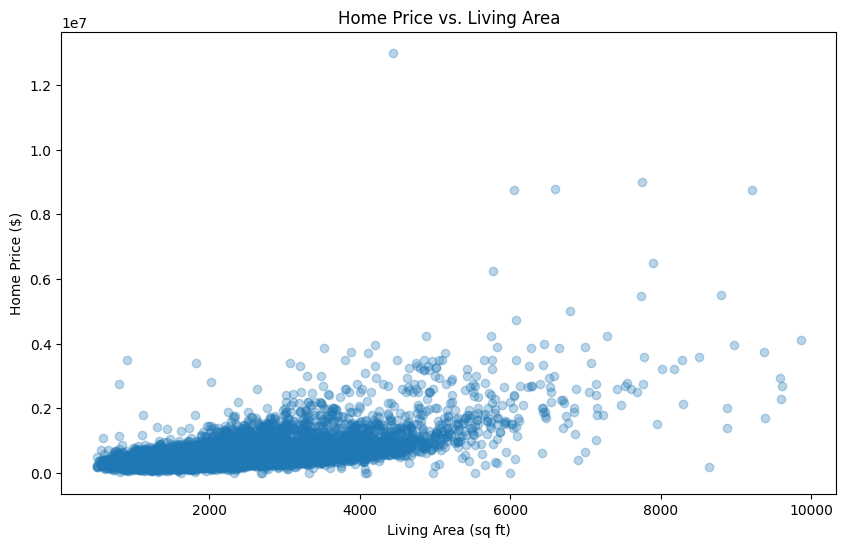

In [338]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_clean["livingAreaSqFt"],
    df_clean["latestPrice"],
    alpha=0.3
)

plt.xlabel("Living Area (sq ft)")
plt.ylabel("Home Price ($)")
plt.title("Home Price vs. Living Area")
plt.savefig("../visualizations/price_by_living_area.png", dpi=300, bbox_inches="tight")

plt.show()

In [339]:
df_clean["livingAreaSqFt"].corr(df_clean["latestPrice"])

np.float64(0.6122879940123778)

In [340]:
correlations = df_clean[[
    "latestPrice",
    "livingAreaSqFt",
    "numOfBedrooms",
    "numOfBathrooms",
    "yearBuilt",
    "garageSpaces",
    "parkingSpaces"
]].corr()["latestPrice"].sort_values(ascending=False)

correlations

latestPrice       1.000000
livingAreaSqFt    0.612288
numOfBathrooms    0.540099
numOfBedrooms     0.334060
garageSpaces      0.157439
parkingSpaces     0.156731
yearBuilt         0.057601
Name: latestPrice, dtype: float64

In [341]:
df_clean["pricePerSqFt"] = (
    df_clean["latestPrice"] / df_clean["livingAreaSqFt"]
)

In [342]:
df_clean["pricePerSqFt"].describe()

count    15012.000000
mean       237.599162
std        125.463538
min          0.933333
25%        162.500128
50%        206.001565
75%        279.715266
max       3887.777778
Name: pricePerSqFt, dtype: float64

In [343]:
bedroom_prices = (
    df_clean.groupby("numOfBedrooms")["latestPrice"]
    .median()
)

bedroom_prices

numOfBedrooms
1      325000.0
2      370000.0
3      355000.0
4      474000.0
5      647877.0
6      812400.0
7     1197500.0
8      457000.0
10     525000.0
Name: latestPrice, dtype: float64

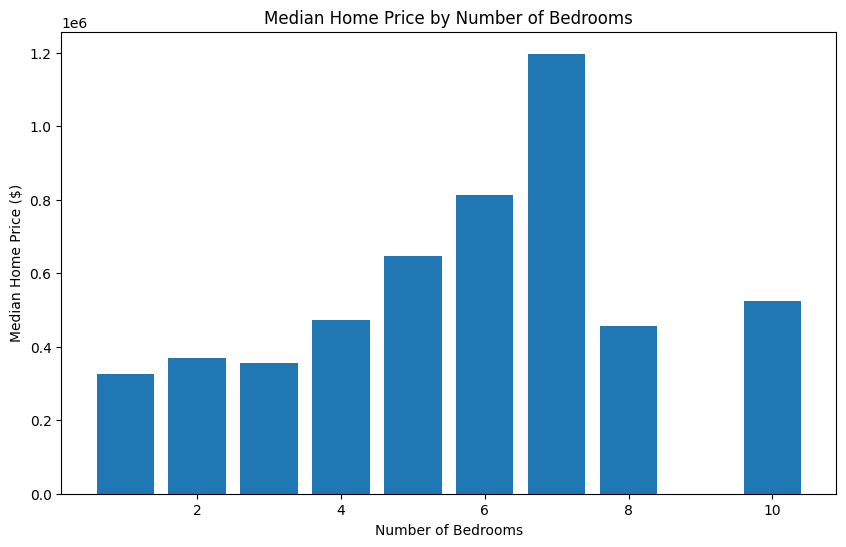

In [344]:
plt.figure(figsize=(10, 6))

plt.bar(
    bedroom_prices.index,
    bedroom_prices.values
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Home Price ($)")
plt.title("Median Home Price by Number of Bedrooms")

plt.show()

In [345]:
bathroom_prices = (
    df_clean.groupby("numOfBathrooms")["latestPrice"]
    .median()
)

bathroom_prices

numOfBathrooms
1.00      349000.0
1.50      375525.0
1.70      379500.0
1.75      580000.0
2.00      350000.0
2.50      325000.0
2.75      895000.0
3.00      420000.0
3.50      552500.0
4.00      624900.0
4.50      599900.0
5.00     1075000.0
5.50     1185000.0
6.00     1512500.0
6.50     2750000.0
7.00     2495000.0
8.00     1599000.0
9.00     2765000.0
10.00    4100000.0
Name: latestPrice, dtype: float64

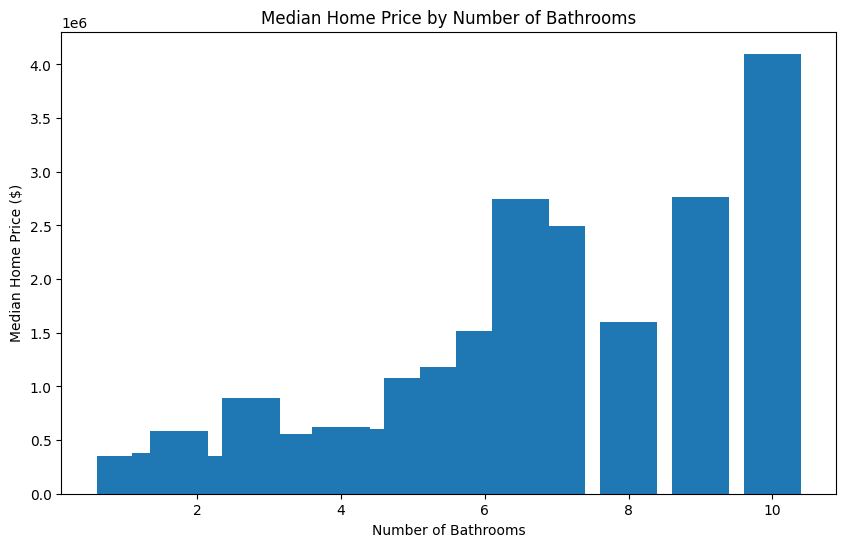

In [346]:
plt.figure(figsize=(10, 6))

plt.bar(
    bathroom_prices.index,
    bathroom_prices.values
)

plt.xlabel("Number of Bathrooms")
plt.ylabel("Median Home Price ($)")
plt.title("Median Home Price by Number of Bathrooms")

plt.show()

In [347]:
bedroom_counts = df_clean["numOfBedrooms"].value_counts().sort_index()
bedroom_counts

numOfBedrooms
1       84
2     1044
3     7408
4     5170
5     1159
6      116
7       12
8       18
10       1
Name: count, dtype: int64

In [348]:
bathroom_counts = df_clean["numOfBathrooms"].value_counts().sort_index()
bathroom_counts

numOfBathrooms
1.00      916
1.50       13
1.70        1
1.75        3
2.00     6094
2.50      126
2.75        2
3.00     5279
3.50       44
4.00     1884
4.50        5
5.00      407
5.50        2
6.00      156
6.50        1
7.00       61
8.00       16
9.00        1
10.00       1
Name: count, dtype: int64

In [349]:
bedroom_prices = (
    df_clean[df_clean["numOfBedrooms"] <= 6]
    .groupby("numOfBedrooms")["latestPrice"]
    .median()
)

bedroom_prices

numOfBedrooms
1    325000.0
2    370000.0
3    355000.0
4    474000.0
5    647877.0
6    812400.0
Name: latestPrice, dtype: float64

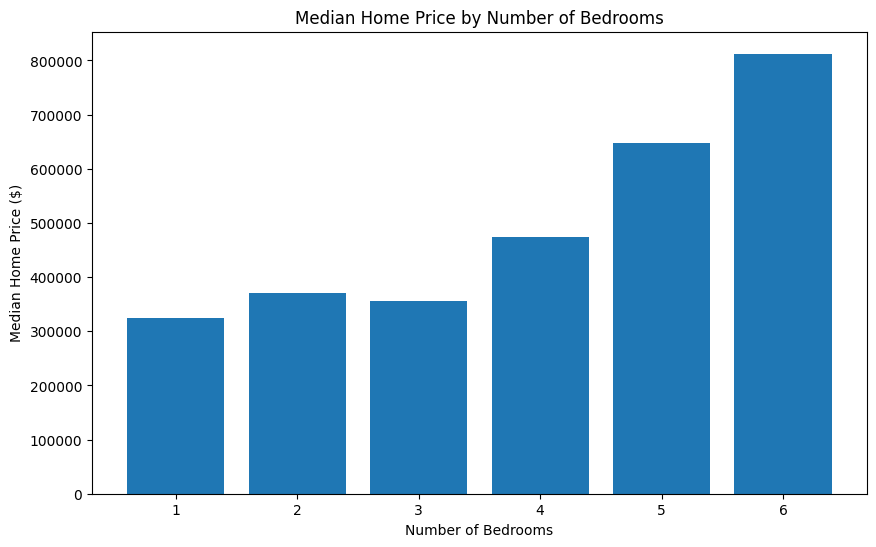

In [350]:
plt.figure(figsize=(10, 6))

plt.bar(
    bedroom_prices.index,
    bedroom_prices.values
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Home Price ($)")
plt.title("Median Home Price by Number of Bedrooms")

plt.show()

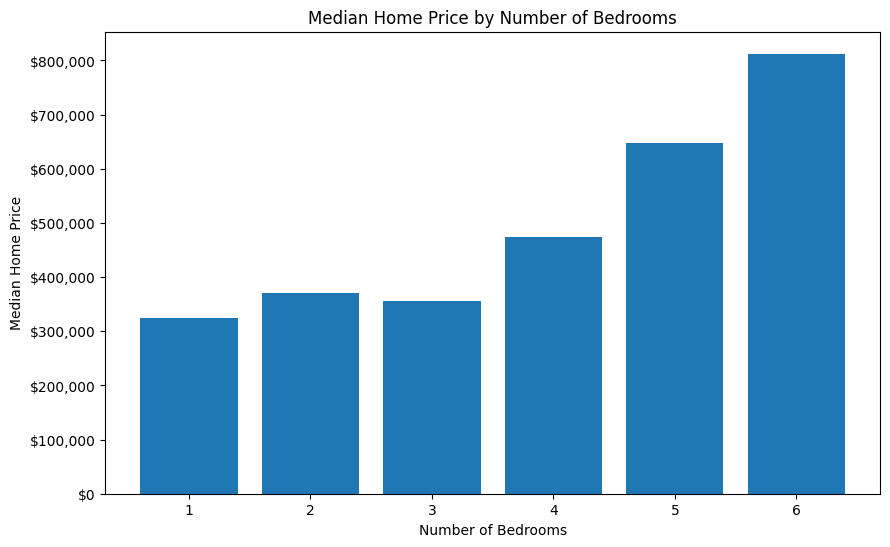

In [351]:
plt.figure(figsize=(10, 6))

plt.bar(
    bedroom_prices.index,
    bedroom_prices.values
)

plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Home Price")
plt.title("Median Home Price by Number of Bedrooms")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.savefig("../visualizations/price_by_bedrooms.png", dpi=300, bbox_inches="tight")
plt.show()

In [352]:
zip_counts = df_clean["zipcode"].value_counts()

zip_counts.head(15)

zipcode
78748    1137
78745    1025
78749     772
78704     692
78737     612
78739     604
78732     590
78759     559
78723     555
78757     519
78717     515
78731     490
78744     469
78753     438
78727     414
Name: count, dtype: int64

In [353]:
zip_analysis = (
    df_clean.groupby("zipcode")
    .agg(
        median_price=("latestPrice", "median"),
        average_price=("latestPrice", "mean"),
        number_of_properties=("latestPrice", "count")
    )
    .query("number_of_properties >= 100")
    .sort_values("median_price", ascending=False)
)

zip_analysis

,median_price,average_price,number_of_properties
zipcode,,,
78746,1144500.0,1.417418e+06,192
78703,990000.0,1.199280e+06,297
78730,887450.0,1.020246e+06,244
78733,775000.0,9.985668e+05,201
78731,750000.0,8.952352e+05,490
78704,699900.0,8.444949e+05,692
78735,649900.0,9.611592e+05,305
78756,604925.0,6.942786e+05,138
78750,585000.0,5.811144e+05,321


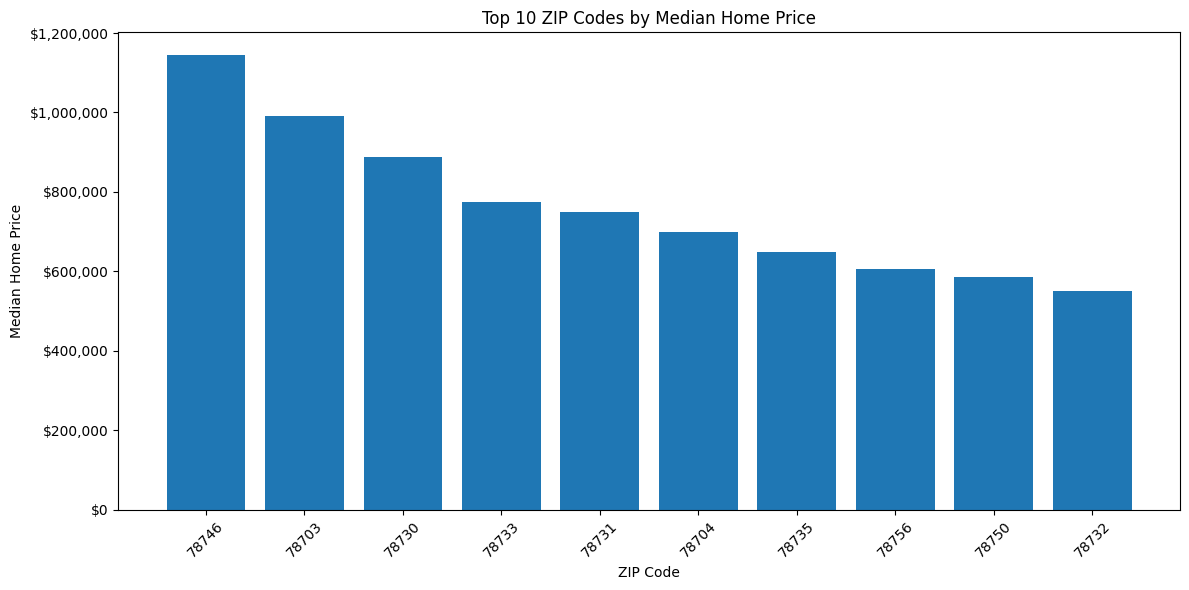

In [354]:
top_zip_codes = zip_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_zip_codes.index.astype(str),
    top_zip_codes["median_price"]
)

plt.xlabel("ZIP Code")
plt.ylabel("Median Home Price")
plt.title("Top 10 ZIP Codes by Median Home Price")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualizations/price_by_zipcode.png", dpi=300, bbox_inches="tight")
plt.show()

In [355]:
bottom_zip_codes = zip_analysis.tail(10).sort_values("median_price")

bottom_zip_codes

,median_price,average_price,number_of_properties
zipcode,,,
78725,204200.0,225183.771605,162
78724,249000.0,278410.107623,223
78754,255000.0,256518.198473,393
78744,259000.0,268279.648188,469
78753,274900.0,282508.582192,438
78747,275000.0,294423.034121,381
78728,305000.0,301206.245536,224
78748,312900.0,322711.277045,1137
78729,335000.0,338760.356467,317


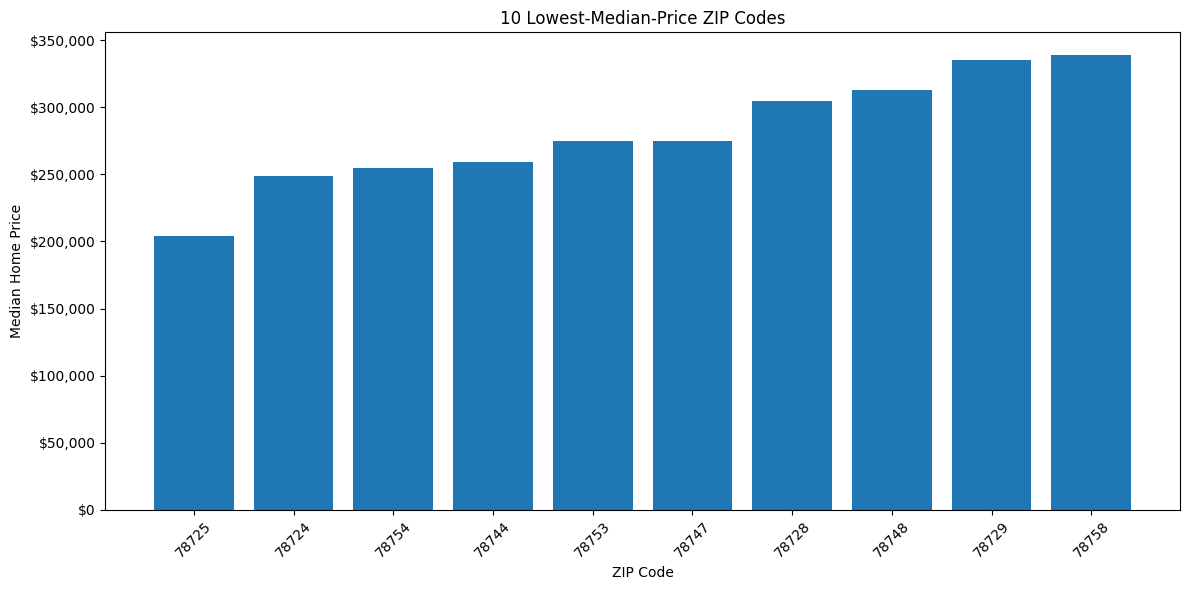

In [356]:
plt.figure(figsize=(12, 6))

plt.bar(
    bottom_zip_codes.index.astype(str),
    bottom_zip_codes["median_price"]
)

plt.xlabel("ZIP Code")
plt.ylabel("Median Home Price")
plt.title("10 Lowest-Median-Price ZIP Codes")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

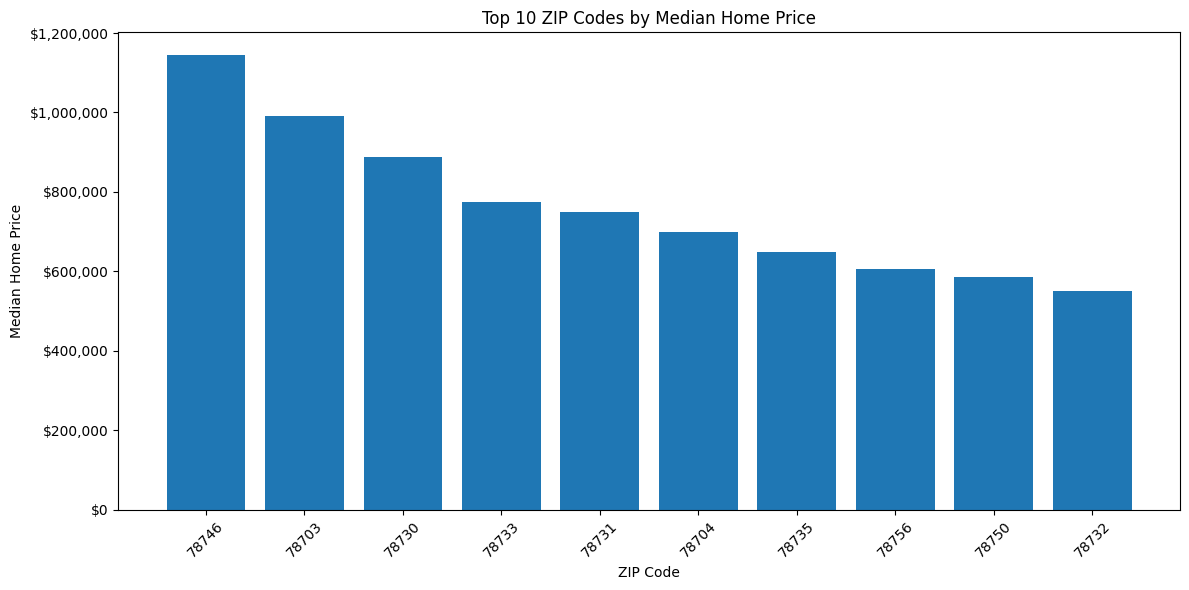

In [357]:
top_zip_codes = zip_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_zip_codes.index.astype(str),
    top_zip_codes["median_price"]
)

plt.xlabel("ZIP Code")
plt.ylabel("Median Home Price")
plt.title("Top 10 ZIP Codes by Median Home Price")

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [358]:
features = [
    "livingAreaSqFt",
    "numOfBedrooms",
    "numOfBathrooms",
    "yearBuilt",
    "garageSpaces",
    "parkingSpaces"
]

X = df_clean[features]
y = df_clean["latestPrice"]

In [359]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [360]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [361]:
y_pred = model.predict(X_test)

In [362]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²: {r2:.3f}")

MAE: $168,732
RMSE: $322,948
R²: 0.488


In [363]:
model_data = df_clean[
    [
        "latestPrice",
        "livingAreaSqFt",
        "numOfBedrooms",
        "numOfBathrooms",
        "yearBuilt",
        "garageSpaces",
        "parkingSpaces",
        "zipcode"
    ]
].copy()

In [364]:
model_data = pd.get_dummies(
    model_data,
    columns=["zipcode"],
    drop_first=True
)

In [365]:
X2 = model_data.drop(columns="latestPrice")
y2 = model_data["latestPrice"]

In [366]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

In [367]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [368]:
y2_pred = model2.predict(X2_test)

In [369]:
mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = mean_squared_error(y2_test, y2_pred) ** 0.5
r2_2 = r2_score(y2_test, y2_pred)

print(f"MAE: ${mae2:,.0f}")
print(f"RMSE: ${rmse2:,.0f}")
print(f"R²: {r2_2:.3f}")

MAE: $137,389
RMSE: $288,365
R²: 0.592


In [370]:
model_data["log_price"] = np.log(model_data["latestPrice"])

In [371]:
X3 = model_data.drop(columns=["latestPrice", "log_price"])
y3 = model_data["log_price"]

In [372]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42
)

In [373]:
model3 = LinearRegression()

model3.fit(X3_train, y3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [374]:
y3_pred = model3.predict(X3_test)

In [375]:
r2_3 = r2_score(y3_test, y3_pred)

print(f"Log-price R²: {r2_3:.3f}")

Log-price R²: 0.632


In [376]:
predicted_prices = np.exp(y3_pred)
actual_prices = np.exp(y3_test)

In [377]:
mae3 = mean_absolute_error(actual_prices, predicted_prices)
rmse3 = mean_squared_error(actual_prices, predicted_prices) ** 0.5

print(f"Model 3 MAE: ${mae3:,.0f}")
print(f"Model 3 RMSE: ${rmse3:,.0f}")

Model 3 MAE: $111,841
Model 3 RMSE: $274,707


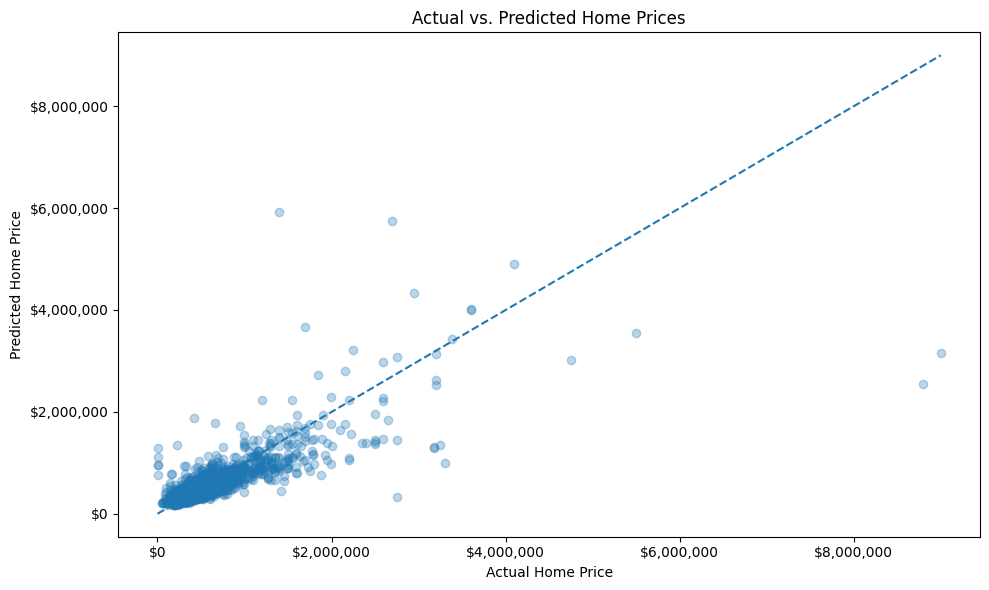

In [378]:
plt.figure(figsize=(10, 6))

plt.scatter(
    actual_prices,
    predicted_prices,
    alpha=0.3
)

max_price = max(actual_prices.max(), predicted_prices.max())

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--"
)

plt.xlabel("Actual Home Price")
plt.ylabel("Predicted Home Price")
plt.title("Actual vs. Predicted Home Prices")

plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [379]:
coefficients = pd.DataFrame({
    "feature": X3.columns,
    "coefficient": model3.coef_
})

coefficients.sort_values(
    "coefficient",
    ascending=False
).head(15)

,feature,coefficient
30,zipcode_78734,1.395708
12,zipcode_78703,1.332465
13,zipcode_78704,1.245492
40,zipcode_78746,1.174015
10,zipcode_78701,1.108079
49,zipcode_78756,1.075417
27,zipcode_78731,1.032175
45,zipcode_78751,1.028694
34,zipcode_78738,1.006363
11,zipcode_78702,0.969430


In [380]:
coefficients.sort_values(
    "coefficient",
    ascending=True
).head(15)

,feature,coefficient
16,zipcode_78719,-0.147400
5,parkingSpaces,-0.052121
1,numOfBedrooms,-0.018731
3,yearBuilt,0.000283
0,livingAreaSqFt,0.000306
2,numOfBathrooms,0.024232
4,garageSpaces,0.070902
37,zipcode_78742,0.107153
21,zipcode_78725,0.118744
8,zipcode_78653,0.134331


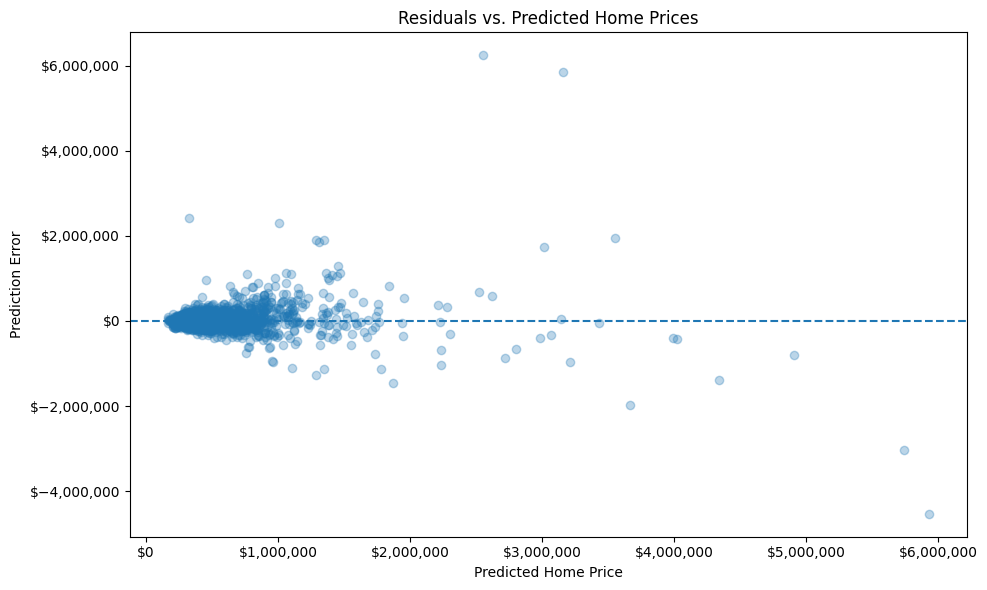

In [381]:
residuals = actual_prices - predicted_prices

plt.figure(figsize=(10, 6))

plt.scatter(
    predicted_prices,
    residuals,
    alpha=0.3
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Home Price")
plt.ylabel("Prediction Error")
plt.title("Residuals vs. Predicted Home Prices")

plt.gca().xaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.savefig("../visualizations/residuals.png", dpi=300, bbox_inches="tight")
plt.show()

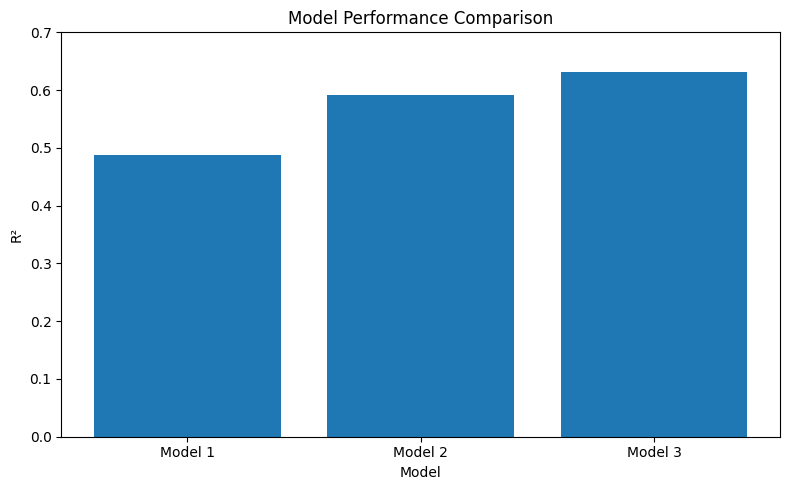

In [382]:
model_names = ["Model 1", "Model 2", "Model 3"]
r2_values = [0.488, 0.592, 0.632]

plt.figure(figsize=(8, 5))

plt.bar(model_names, r2_values)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title("Model Performance Comparison")

plt.ylim(0, 0.7)

plt.tight_layout()
plt.savefig("../visualizations/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [383]:
model_comparison = pd.DataFrame({
    "Model": [
        "Model 1",
        "Model 2",
        "Model 3"
    ],
    "Description": [
        "Housing characteristics",
        "Characteristics + ZIP code",
        "Characteristics + ZIP code + log(price)"
    ],
    "R2": [
        0.488,
        0.592,
        0.632
    ],
    "MAE": [
        168732,
        137389,
        111841
    ],
    "RMSE": [
        322948,
        288365,
        274707
    ]
})

model_comparison

,Model,Description,R2,MAE,RMSE
0,Model 1,Housing characteristics,0.488,168732,322948
1,Model 2,Characteristics + ZIP code,0.592,137389,288365
2,Model 3,Characteristics + ZIP code + log(price),0.632,111841,274707
